In [ ]:
import zipfile
import os

# Path to the zip file
zip_path = 'path/to/your/file.zip'

# Directory to extract to
extract_dir = 'path/to/extract/directory'

# Make sure the output directory exists
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipping complete.")


In [ ]:
def create_comparison_charts(comparison_df, output_dir):
    """Create comprehensive comparison charts for all models"""
    model_names = [name.split('/')[-1] for name in comparison_df["model_name"]]

    # 1. Accuracy and Inference Time Comparison
    plt.figure(figsize=(15, 10))

    # Accuracy chart
    plt.subplot(2, 1, 1)
    accuracies = comparison_df["accuracy"]

    # Sort by accuracy
    sorted_indices = np.argsort(accuracies)[::-1]
    sorted_model_names = [model_names[i] for i in sorted_indices]
    sorted_accuracies = [accuracies[i] for i in sorted_indices]

    bars = plt.bar(sorted_model_names, sorted_accuracies, color='cornflowerblue')
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)

    # Add accuracy values on top of bars
    for bar, acc in zip(bars, sorted_accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', va='bottom')

    # Inference time chart
    plt.subplot(2, 1, 2)
    times = comparison_df["avg_inference_time"]
    sorted_times = [times[i] for i in sorted_indices]

    bars = plt.bar(sorted_model_names, sorted_times, color='salmon')
    plt.ylabel('Average Inference Time (s)')
    plt.title('Model Speed Comparison')
    plt.xticks(rotation=45, ha='right')

    # Add time values on top of bars
    for bar, t in zip(bars, sorted_times):  # Fixed this line - removed 'import json'
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{t:.3f}s', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/accuracy_speed_comparison.png")
    plt.close()

import os
import torch
import json
from PIL import Image
from transformers import (
    ViltProcessor, ViltForQuestionAnswering,
    BlipProcessor, BlipForQuestionAnswering,
    Blip2Processor, Blip2ForConditionalGeneration,
    AutoProcessor, AutoModelForVision2Seq,
    CLIPProcessor, CLIPModel,
    LlavaProcessor, LlavaForConditionalGeneration,
    Pix2StructProcessor, Pix2StructForConditionalGeneration
)
from tqdm import tqdm
import random
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
import time
import matplotlib.pyplot as plt
from scipy.special import softmax
import torch.nn.functional as F

class BaseVQAModel:
    """Base class for all VQA models"""
    def __init__(self, model_name):
        self.model_name = model_name
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

    def predict(self, image_path, question, possible_answers):
        """To be implemented by child classes"""
        raise NotImplementedError

    def evaluate(self, dataset, sample_size=None, output_dir="vqa_results"):
        """Evaluate this specific model on the dataset"""
        os.makedirs(output_dir, exist_ok=True)

        if sample_size and sample_size < len(dataset):
            eval_dataset = random.sample(dataset, sample_size)
        else:
            eval_dataset = dataset

        predictions = []
        ground_truth = []
        results = []

        total_time = 0
        num_samples = len(eval_dataset)

        for item in tqdm(eval_dataset, desc=f"Evaluating {self.model_name}"):
            # Shuffle options to avoid position bias
            options = item["options"].copy()
            random.shuffle(options)

            # Run prediction and measure time
            start_time = time.time()
            pred = self.predict(
                image_path=item["image_path"],
                question=item["question"],
                possible_answers=options
            )
            end_time = time.time()
            inference_time = end_time - start_time
            total_time += inference_time

            # Store results
            predictions.append(pred)
            ground_truth.append(item["correct_answer"])

            results.append({
                "image_id": item["image_id"],
                "question": item["question"],
                "prediction": pred,
                "correct_answer": item["correct_answer"],
                "is_correct": pred == item["correct_answer"],
                "inference_time": inference_time
            })

        # Calculate metrics
        accuracy = accuracy_score(ground_truth, predictions)
        avg_inference_time = total_time / num_samples if num_samples > 0 else 0

        # Create a DataFrame for analysis
        results_df = pd.DataFrame(results)

        # Calculate accuracy per question type
        question_accuracy = results_df.groupby("question")["is_correct"].mean().to_dict()

        # Save results
        model_name_safe = self.model_name.split('/')[-1]
        results_df.to_csv(f"{output_dir}/{model_name_safe}_results.csv", index=False)

        # Create individual model performance charts
        self._create_model_charts(results_df, output_dir, model_name_safe)

        metrics = {
            "model_name": self.model_name,
            "accuracy": accuracy,
            "avg_inference_time": avg_inference_time,
            "question_accuracy": question_accuracy,
            "memory_usage": self._get_model_memory_size()
        }

        return metrics, results_df

    def _get_model_memory_size(self):
        """Get the model's memory footprint in MB"""
        try:
            # This is an approximation based on parameters - works for most PyTorch models
            model_size = sum(p.numel() * p.element_size() for p in self.model.parameters()) / (1024 * 1024)
            return f"{model_size:.2f} MB"
        except:
            return "Unknown"

    def _create_model_charts(self, results_df, output_dir, model_name_safe):
        """Create performance charts for a single model"""
        # 1. Question type accuracy chart
        plt.figure(figsize=(10, 6))
        question_accuracy = results_df.groupby("question")["is_correct"].mean().sort_values(ascending=False)

        bars = plt.bar(question_accuracy.index, question_accuracy.values)
        plt.ylabel('Accuracy')
        plt.title(f'{model_name_safe} - Accuracy by Question Type')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{model_name_safe}_question_accuracy.png")
        plt.close()

        # 2. Inference time distribution
        plt.figure(figsize=(8, 6))
        plt.hist(results_df['inference_time'], bins=20, alpha=0.7, color='skyblue')
        plt.axvline(results_df['inference_time'].mean(), color='red', linestyle='dashed', linewidth=2)
        plt.title(f'{model_name_safe} - Inference Time Distribution')
        plt.xlabel('Inference Time (seconds)')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{model_name_safe}_time_distribution.png")
        plt.close()


class BlipVQA(BaseVQAModel):
    """BLIP model for VQA - Lightweight option"""
    def __init__(self, model_name="Salesforce/blip-vqa-capfilt-large"):
        super().__init__(model_name)
        self.processor = BlipProcessor.from_pretrained(model_name)
        self.model = BlipForQuestionAnswering.from_pretrained(model_name).to(self.device)

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # BLIP doesn't directly support multiple-choice, so we'll score each answer
            best_score = -float('inf')
            best_answer = None

            for answer in possible_answers:
                # Process inputs for this answer
                inputs = self.processor(image, f"{question} Answer: {answer}", return_tensors="pt").to(self.device)

                # Forward pass
                with torch.no_grad():
                    outputs = self.model(**inputs)

                # Get probability score
                score = outputs.logits[0][0].item()  # Probability of being correct

                if score > best_score:
                    best_score = score
                    best_answer = answer

            return best_answer
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            # Return first answer instead of None to avoid mixing types
            return possible_answers[0] if possible_answers else "Unknown"


class ClipVQA(BaseVQAModel):
    """CLIP model adapted for VQA tasks - very efficient"""
    def __init__(self, model_name="openai/clip-vit-base-patch32"):
        super().__init__(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model = CLIPModel.from_pretrained(model_name).to(self.device)

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Prepare image input
            image_inputs = self.processor(
                images=image,
                return_tensors="pt"
            ).to(self.device)

            # Prepare text candidates combining question with each possible answer
            text_candidates = [f"{question} {answer}" for answer in possible_answers]
            text_inputs = self.processor(
                text=text_candidates,
                return_tensors="pt",
                padding=True
            ).to(self.device)

            # Get embeddings
            with torch.no_grad():
                image_features = self.model.get_image_features(**image_inputs)
                text_features = self.model.get_text_features(**text_inputs)

            # Normalize features
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            # Compute similarity scores
            similarity_scores = (image_features @ text_features.T).squeeze(0)

            # Get the predicted answer
            predicted_idx = similarity_scores.argmax().item()
            predicted_answer = possible_answers[predicted_idx]

            return predicted_answer
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class OWLvitVQA(BaseVQAModel):
    """OWL-ViT model for VQA - efficient object detection model adapted for VQA"""
    def __init__(self, model_name="google/owlvit-base-patch32"):
        super().__init__(model_name)
        from transformers import OwlViTProcessor, OwlViTForObjectDetection
        self.processor = OwlViTProcessor.from_pretrained(model_name)
        self.model = OwlViTForObjectDetection.from_pretrained(model_name).to(self.device)

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # For object-related questions, we'll detect objects and match them to answers
            with torch.no_grad():
                # Process inputs
                inputs = self.processor(
                    text=[f"{answer}" for answer in possible_answers],
                    images=image,
                    return_tensors="pt"
                ).to(self.device)

                # Forward pass
                outputs = self.model(**inputs)

                # Get scores for each answer
                target_sizes = torch.Tensor([[image.size[1], image.size[0]]]).to(self.device)
                scores = []

                # Get logits per answer
                for i in range(len(possible_answers)):
                    # Get detection scores for this answer
                    score = torch.max(outputs.logits[0, i]).item()
                    scores.append(score)

                # Get the predicted answer
                predicted_idx = np.argmax(scores)
                predicted_answer = possible_answers[predicted_idx]

            return predicted_answer
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class LlavaVQA(BaseVQAModel):
    """LLaVA model for VQA - Vision-Language model with LLM reasoning"""
    def __init__(self, model_name="llava-hf/llava-1.5-7b-hf"):
        super().__init__(model_name)
        try:
            self.processor = LlavaProcessor.from_pretrained(model_name)
            self.model = LlavaForConditionalGeneration.from_pretrained(
                model_name,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                device_map="auto" if torch.cuda.is_available() else None
            )
        except Exception as e:
            print(f"Error loading LLaVA model: {e}")
            # Fallback to a smaller version if the requested one fails
            fallback_model = "llava-hf/llava-1.5-7b-hf"
            print(f"Falling back to {fallback_model}")
            self.processor = LlavaProcessor.from_pretrained(fallback_model)
            self.model = LlavaForConditionalGeneration.from_pretrained(
                fallback_model,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                device_map="auto" if torch.cuda.is_available() else None
            )

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Construct a prompt with multiple choices
            options_text = ", ".join(f"({chr(97+i)}) {option}" for i, option in enumerate(possible_answers))
            prompt = f"<image>\n{question}\nChoose the best answer from: {options_text}\nAnswer with just the letter of the correct option."

            # Process inputs
            inputs = self.processor(prompt, image, return_tensors="pt").to(self.device)

            # Generate answer
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=20,
                    do_sample=False
                )
                generated_text = self.processor.decode(outputs[0], skip_special_tokens=True)

            # Look for option letters in the response
            for i, _ in enumerate(possible_answers):
                option_letter = chr(97+i)  # a, b, c, ...

                # Check for various formats the model might use to indicate an answer
                patterns = [
                    f"({option_letter})",
                    f"{option_letter})",
                    f"option {option_letter}",
                    f"answer {option_letter}",
                    f"answer is {option_letter}",
                    f"choice {option_letter}"
                ]

                for pattern in patterns:
                    if pattern.lower() in generated_text.lower():
                        return possible_answers[i]

            # If no option letter found, check for direct answer text
            for i, answer in enumerate(possible_answers):
                if answer.lower() in generated_text.lower():
                    return answer

            # Fallback: return the first option
            return possible_answers[0]

        except Exception as e:
            print(f"Error processing {image_path} with LLaVA: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class InstructBlipVQA(BaseVQAModel):
    """InstructBLIP model for VQA - instruction-tuned vision-language model"""
    def __init__(self, model_name="Salesforce/instructblip-flan-t5-xl"):
        super().__init__(model_name)
        try:
            self.processor = AutoProcessor.from_pretrained(model_name)
            self.model = AutoModelForVision2Seq.from_pretrained(
                model_name,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                device_map="auto" if torch.cuda.is_available() else None
            )
        except Exception as e:
            print(f"Error loading InstructBLIP model: {e}")
            # Fallback to a smaller version
            fallback_model = "Salesforce/instructblip-flan-t5-xl"
            print(f"Falling back to {fallback_model}")
            self.processor = AutoProcessor.from_pretrained(fallback_model)
            self.model = AutoModelForVision2Seq.from_pretrained(fallback_model).to(self.device)

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Construct a prompt with multiple choices
            options_text = ", ".join(f"({chr(97+i)}) {option}" for i, option in enumerate(possible_answers))
            prompt = f"{question}\nChoose one answer from: {options_text}"

            # Process inputs
            inputs = self.processor(images=image, text=prompt, return_tensors="pt").to(self.device)

            # Generate answer
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=20,
                    do_sample=False
                )
                generated_text = self.processor.decode(outputs[0], skip_special_tokens=True)

            # Look for option letters or direct matches
            for i, option in enumerate(possible_answers):
                # Check for option letter
                option_letter = f"({chr(97+i)})"
                if option_letter in generated_text:
                    return option

                # Check for direct match
                if option.lower() in generated_text.lower():
                    return option

            # Fallback to first option
            return possible_answers[0]

        except Exception as e:
            print(f"Error processing {image_path} with InstructBLIP: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class PaliGemmaVQA(BaseVQAModel):
    """PaLI-Gemma model for VQA - Google's multimodal model combining PaLI and Gemma"""
    def __init__(self, model_name="google/paligemma-3b-mix-224"):
        super().__init__(model_name)
        try:
            self.processor = AutoProcessor.from_pretrained(model_name)
            self.model = AutoModelForVision2Seq.from_pretrained(
                model_name,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                device_map="auto" if torch.cuda.is_available() else None
            )
        except Exception as e:
            print(f"Error loading PaLI-Gemma model: {e}")
            # Fallback to a smaller version
            fallback_model = "google/paligemma-3b-mix-224"
            print(f"Falling back to {fallback_model}")
            self.processor = AutoProcessor.from_pretrained(fallback_model)
            self.model = AutoModelForVision2Seq.from_pretrained(fallback_model).to(self.device)

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Format question for PaLI-Gemma
            options_text = ", ".join(f"({chr(97+i)}) {option}" for i, option in enumerate(possible_answers))
            prompt = f"<image>\n{question}\nChoose from: {options_text}"

            # Process inputs
            inputs = self.processor(images=image, text=prompt, return_tensors="pt").to(self.device)

            # Generate answer
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=30,
                    do_sample=False
                )
                generated_text = self.processor.decode(outputs[0], skip_special_tokens=True)

            # Parse the answer - first check option letters
            for i, _ in enumerate(possible_answers):
                option_letter = chr(97+i)  # a, b, c, ...
                patterns = [
                    f"({option_letter})",
                    f"{option_letter})",
                    f"option {option_letter}",
                    f"answer {option_letter}"
                ]

                for pattern in patterns:
                    if pattern.lower() in generated_text.lower():
                        return possible_answers[i]

            # Check for direct matches
            for answer in possible_answers:
                if answer.lower() in generated_text.lower():
                    return answer

            # Fallback to first option
            return possible_answers[0]

        except Exception as e:
            print(f"Error processing {image_path} with PaLI-Gemma: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class RVQA(BaseVQAModel):
    """R-VQA model - uses a Pix2Struct backbone which is efficient for reasoning tasks"""
    def __init__(self, model_name="google/pix2struct-textcaps-large"):
        super().__init__(model_name)
        try:
            self.processor = Pix2StructProcessor.from_pretrained(model_name)
            self.model = Pix2StructForConditionalGeneration.from_pretrained(model_name).to(self.device)
        except Exception as e:
            print(f"Error loading R-VQA model: {e}")
            fallback = "google/pix2struct-base"
            print(f"Falling back to {fallback}")
            self.processor = Pix2StructProcessor.from_pretrained(fallback)
            self.model = Pix2StructForConditionalGeneration.from_pretrained(fallback).to(self.device)

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Format options
            options_text = "\n".join(f"{chr(97+i)}. {option}" for i, option in enumerate(possible_answers))
            prompt = f"{question}\n\nOptions:\n{options_text}\n\nAnswer:"

            # Process inputs
            inputs = self.processor(images=image, text=prompt, return_tensors="pt").to(self.device)

            # Generate answer
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=10
                )
                generated_text = self.processor.decode(outputs[0], skip_special_tokens=True)

            # Parse the result
            generated_text = generated_text.strip().lower()

            # Check for option letters
            for i, _ in enumerate(possible_answers):
                letter = chr(97 + i)  # a, b, c, ...
                if generated_text.startswith(letter) or f"option {letter}" in generated_text or f"({letter})" in generated_text:
                    return possible_answers[i]

            # Check for exact matches
            for i, answer in enumerate(possible_answers):
                if answer.lower() in generated_text:
                    return answer

            # Default to first answer if no match found
            return possible_answers[0]

        except Exception as e:
            print(f"Error processing {image_path} with R-VQA: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class ClipUpVQA(BaseVQAModel):
    """CLIP-UP (CLIP with Unified Prompts) adapter for VQA"""
    def __init__(self, model_name="openai/clip-vit-large-patch14"):
        super().__init__(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model = CLIPModel.from_pretrained(model_name).to(self.device)

        # Templates for unified prompting
        self.templates = [
            "A photo of {}",
            "An image of {}",
            "A picture showing {}",
            "This is a photo of {}"
        ]

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Process image
            image_inputs = self.processor(
                images=image,
                return_tensors="pt"
            ).to(self.device)

            # Generate embeddings for all possible answers with templates
            best_score = -float('inf')
            best_answer = None

            # Get image features once
            with torch.no_grad():
                image_features = self.model.get_image_features(**image_inputs)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # For each answer, try different templates
            all_texts = []
            template_map = []  # Keep track of which template and answer each text comes from

            for answer in possible_answers:
                # Combine question and answer
                for template in self.templates:
                    if "?" in question:
                        # If question ends with ?, replace it with the templated answer
                        text = question.replace("?", f"? {template.format(answer)}")
                    else:
                        # Otherwise just append
                        text = f"{question}. {template.format(answer)}"

                    all_texts.append(text)
                    template_map.append(answer)

            # Process all text candidates at once
            text_inputs = self.processor(
                text=all_texts,
                return_tensors="pt",
                padding=True,
                truncation=True
            ).to(self.device)

            # Get text features
            with torch.no_grad():
                text_features = self.model.get_text_features(**text_inputs)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            # Compute similarities
            similarities = (image_features @ text_features.T).squeeze(0)

            # Find best match across all templates
            best_idx = similarities.argmax().item()
            best_answer = template_map[best_idx]

            return best_answer
        except Exception as e:
            print(f"Error processing {image_path} with CLIP-UP: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class AnswerMeVQA(BaseVQAModel):
    """Answer-Me VQA model - uses a BLIP2 model with specialized prompting"""
    def __init__(self, model_name="Salesforce/blip2-opt-2.7b"):
        super().__init__(model_name)
        self.processor = Blip2Processor.from_pretrained(model_name)
        self.model = Blip2ForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            device_map="auto" if torch.cuda.is_available() else None
        )

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Create task-specific prompt
            options_text = "\n".join([f"{chr(97+i)}. {ans}" for i, ans in enumerate(possible_answers)])
            prompt = f"Answer the following question about the image by selecting the correct option.\n\nQuestion: {question}\n\nOptions:\n{options_text}\n\nThe answer is"

            # Process inputs
            inputs = self.processor(image, prompt, return_tensors="pt").to(self.device)

            # Generate answer
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=10,
                    do_sample=False
                )

                generated_text = self.processor.decode(outputs[0], skip_special_tokens=True).strip().lower()

            # Extract the answer - check for option letters first
            for i, _ in enumerate(possible_answers):
                option_letter = chr(97+i)  # a, b, c, ...

                if f"{option_letter}." in generated_text or f"option {option_letter}" in generated_text or f"({option_letter})" in generated_text:
                    return possible_answers[i]

            # Check for direct matches
            for answer in possible_answers:
                if answer.lower() in generated_text:
                    return answer

            # Fallback - return first option
            return possible_answers[0]

        except Exception as e:
            print(f"Error processing {image_path} with Answer-Me: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class LiteBlipVQA(BaseVQAModel):
    """Lightweight BLIP-2 model for VQA - more efficient than standard BLIP-2"""
    def __init__(self, model_name="Salesforce/blip2-flan-t5-xl"):
        super().__init__(model_name)
        self.processor = Blip2Processor.from_pretrained(model_name)
        self.model = Blip2ForConditionalGeneration.from_pretrained(model_name).to(self.device)

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Format question with a multiple choice prompt
            options_text = ", ".join(f"({chr(97+i)}) {option}" for i, option in enumerate(possible_answers))
            prompt = f"{question}\nChoose from: {options_text}"

            # Process inputs
            inputs = self.processor(image, prompt, return_tensors="pt").to(self.device)

            # Generate answer
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=10,
                    do_sample=False
                )
                generated_text = self.processor.decode(outputs[0], skip_special_tokens=True).strip().lower()

            # Try to match the answer
            best_match = None
            highest_match_score = -1

            # First try direct option letter match
            for i, _ in enumerate(possible_answers):
                option_letter = chr(97+i)
                if f"({option_letter})" in generated_text:
                    return possible_answers[i]

            # Then try exact text match
            for i, answer in enumerate(possible_answers):
                if answer.lower() in generated_text:
                    return answer

            # Last resort: return first option
            return possible_answers[0]
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return possible_answers[0] if possible_answers else "Unknown"


class PnPVQA(BaseVQAModel):
    """Plug-and-Play VQA - uses CLIP for vision and compares multiple textual hypotheses"""
    def __init__(self, model_name="openai/clip-vit-base-patch32"):
        super().__init__(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model = CLIPModel.from_pretrained(model_name).to(self.device)

        # PnP prompt templates
        self.hypothesis_templates = [
            "The answer to the question '{}' is '{}'.",
            "Q: {} A: {}",
            "Question: {} Answer: {}"
        ]

    def predict(self, image_path, question, possible_answers):
        try:
            image = Image.open(image_path).convert("RGB")

            # Process image
            image_inputs = self.processor(
                images=image,
                return_tensors="pt"
            ).to(self.device)

            # Get image features
            with torch.no_grad():
                image_features = self.model.get_image_features(**image_inputs)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # For each possible answer, create multiple hypotheses using templates
            all_hypotheses = []
            hypothesis_to_answer = {}

            for answer in possible_answers:
                for template in self.hypothesis_templates:
                    hypothesis = template.format(question, answer)
                    all_hypotheses.append(hypothesis)
                    hypothesis_to_answer[hypothesis] = answer

            # Process all hypotheses
            text_inputs = self.processor(
                text=all_hypotheses,
                return_tensors="pt",
                padding=True,
                truncation=True
            ).to(self.device)

            # Get text features
            with torch.no_grad():
                text_features = self.model.get_text_features(**text_inputs)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            # Compute image-text similarities
            similarities = (image_features @ text_features.T).squeeze(0)

            # Find best match
            best_idx = similarities.argmax().item()
            best_hypothesis = all_hypotheses[best_idx]
            best_answer = hypothesis_to_answer[best_hypothesis]

            return best_answer
        except Exception as e:
            print(f"Error processing {image_path} with PnP-VQA: {e}")
            return possible_answers[0] if possible_answers else "Unknown"



def load_dataset(json_file_path):
    """Load the dataset from the JSON file"""
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    return data


def process_dataset(data):
    """Process the dataset into a format suitable for evaluation"""
    results = []

    for image_id, image_data in data.items():
        if "path" not in image_data:
            continue

        image_path = image_data["path"]
        # Use the image path directly since they're absolute paths

        for question_text, qa_data in image_data.items():
            # Skip the path key
            if question_text == "path":
                continue

            # Handle both format types in your sample
            if "correct_option" in qa_data:
                correct_answer = qa_data["correct_option"]
                plausible_options = qa_data["plausible_options"]
            # elif "correct" in qa_data:
            #     correct_answer = qa_data["correct"]
            #     plausible_options = qa_data["plausible"]
            else:
                continue

            # Combine correct answer with plausible options
            all_options = [correct_answer] + plausible_options

            results.append({
                "image_id": image_id,
                "image_path": image_path,
                "question": question_text,
                "options": all_options,
                "correct_answer": correct_answer
            })

    return results


def analyze_dataset(dataset):
    """Analyze dataset characteristics for better understanding"""
    # Count unique questions
    questions = [item["question"] for item in dataset]
    unique_questions = set(questions)

    # Question frequency
    question_counts = {}
    for q in questions:
        question_counts[q] = question_counts.get(q, 0) + 1

    # Sort by frequency
    sorted_questions = sorted(question_counts.items(), key=lambda x: x[1], reverse=True)

    # Count unique images
    unique_images = len(set([item["image_path"] for item in dataset]))

    # Average number of options
    avg_options = sum(len(item["options"]) for item in dataset) / len(dataset)

    analysis = {
        "total_qa_pairs": len(dataset),
        "unique_questions": len(unique_questions),
        "unique_images": unique_images,
        "avg_options_per_question": avg_options,
        "top_5_questions": sorted_questions[:5]
    }

    return analysis


def compare_models(dataset, models, sample_size=None, output_dir="vqa_results"):
    """Compare multiple VQA models on the same dataset"""
    os.makedirs(output_dir, exist_ok=True)

    all_metrics = []

    # Run evaluations for each model separately
    for model in models:
        print(f"\nEvaluating model: {model.model_name}")
        metrics, _ = model.evaluate(dataset, sample_size, output_dir)
        all_metrics.append(metrics)

    # Create comparison dataframe
    comparison_df = pd.DataFrame(all_metrics)
    comparison_df.to_csv(f"{output_dir}/model_comparison.csv", index=False)

    # Create comparison charts
    create_comparison_charts(comparison_df, output_dir)

    return comparison_df


def create_comparison_charts(comparison_df, output_dir):
    """Create comprehensive comparison charts for all models"""
    model_names = [name.split('/')[-1] for name in comparison_df["model_name"]]

    # 1. Accuracy and Inference Time Comparison
    plt.figure(figsize=(15, 10))

    # Accuracy chart
    plt.subplot(2, 1, 1)
    accuracies = comparison_df["accuracy"]

    bars = plt.bar(model_names, accuracies, color='cornflowerblue')
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)

    # Add accuracy values on top of bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', va='bottom')

    # Inference time chart
    plt.subplot(2, 1, 2)
    times = comparison_df["avg_inference_time"]

    bars = plt.bar(model_names, times, color='salmon')
    plt.ylabel('Average Inference Time (s)')
    plt.title('Model Speed Comparison')
    plt.xticks(rotation=45, ha='right')

    # Add time values on top of bars
    for bar, t in zip(bars, times):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{t:.3f}s', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/accuracy_speed_comparison.png")
    plt.close()

    # 2. Efficiency chart (accuracy/time ratio)
    plt.figure(figsize=(12, 6))

    # Calculate efficiency (accuracy per second)
    efficiency = comparison_df["accuracy"] / comparison_df["avg_inference_time"]

    bars = plt.bar(model_names, efficiency, color='mediumseagreen')
    plt.ylabel('Efficiency (Accuracy/Second)')
    plt.title('Model Efficiency Comparison')
    plt.xticks(rotation=45, ha='right')

    # Add efficiency values on top of bars
    for bar, eff in zip(bars, efficiency):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{eff:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/efficiency_comparison.png")
    plt.close()

    # 3. Question-type accuracy heatmap
    try:
        # Extract question accuracy data
        question_accuracy_data = comparison_df["question_accuracy"].tolist()

        # Get all unique questions across all models
        all_questions = set()
        for q_acc in question_accuracy_data:
            all_questions.update(q_acc.keys())

        # Create a matrix for the heatmap
        questions_list = sorted(list(all_questions))
        heatmap_data = np.zeros((len(model_names), len(questions_list)))

        for i, q_acc in enumerate(question_accuracy_data):
            for j, q in enumerate(questions_list):
                heatmap_data[i, j] = q_acc.get(q, 0)  # Default to 0 if not present

        # Plot heatmap
        plt.figure(figsize=(max(12, len(questions_list)), max(8, len(model_names))))

        plt.imshow(heatmap_data, cmap='viridis', aspect='auto')
        plt.colorbar(label='Accuracy')
        plt.xlabel('Question Type')
        plt.ylabel('Model')
        plt.title('Question-specific Accuracy by Model')

        plt.xticks(range(len(questions_list)), questions_list, rotation=90)
        plt.yticks(range(len(model_names)), model_names)

        plt.tight_layout()
        plt.savefig(f"{output_dir}/question_accuracy_heatmap.png")
        plt.close()
    except Exception as e:
        print(f"Could not create question accuracy heatmap: {e}")


def generate_report(comparison_df, dataset_analysis, output_dir):
    """Generate a comprehensive markdown report of the comparison"""
    os.makedirs(output_dir, exist_ok=True)

    report = f"""# Visual Question Answering Model Comparison Report

## Dataset Overview
- Total QA Pairs: {dataset_analysis['total_qa_pairs']}
- Unique Questions: {dataset_analysis['unique_questions']}
- Unique Images: {dataset_analysis['unique_images']}
- Average Options per Question: {dataset_analysis['avg_options_per_question']:.2f}

### Top 5 Most Common Questions
{chr(10).join([f"- '{q}': {count} occurrences" for q, count in dataset_analysis['top_5_questions']])}

## Model Performance Summary

| Model | Accuracy | Avg. Inference Time (s) | Memory Usage |
|-------|----------|------------------------|-------------|
"""

    # Add rows for each model
    for _, row in comparison_df.iterrows():
        model_name = row["model_name"].split('/')[-1]
        accuracy = row["accuracy"]
        time = row["avg_inference_time"]
        memory = row["memory_usage"]

        report += f"| {model_name} | {accuracy:.4f} | {time:.4f} | {memory} |\n"

    # Add model descriptions
    report += """
## Model Descriptions

### ViLT
Vision-and-Language Transformer without convolutions or regions, offering a lightweight and efficient approach for multimodal learning.

### BLIP
Bootstrapping Language-Image Pre-training for unified vision-language understanding and generation.

### CLIP
Contrastive Language-Image Pre-training connects text and images in a shared embedding space, performing well at zero-shot tasks.

### OWL-ViT
Open-vocabulary object detection model that can identify diverse objects described by free-text queries.

### LiteBLIP
A more efficient version of BLIP-2 with smaller language model components.

## Performance Analysis

The charts in this directory show:
- Accuracy comparison across models
- Inference time comparison
- Efficiency (accuracy/time) comparison
- Performance on different question types

## Strengths and Weaknesses

"""

    # Add strengths and weaknesses based on question accuracy
    try:
        for i, row in comparison_df.iterrows():
            model_name = row["model_name"].split('/')[-1]
            q_acc = row["question_accuracy"]

            # Find strongest and weakest questions
            sorted_q = sorted(q_acc.items(), key=lambda x: x[1], reverse=True)

            report += f"### {model_name}\n"
            report += "**Strengths:** Best at answering "
            report += ", ".join([f"'{q}' ({acc:.2f})" for q, acc in sorted_q[:3]])
            report += "\n\n**Weaknesses:** Struggles with "
            report += ", ".join([f"'{q}' ({acc:.2f})" for q, acc in sorted_q[-3:]])
            report += "\n\n"
    except:
        report += "Question-specific performance analysis could not be generated.\n\n"

    # Write report to file
    with open(f"{output_dir}/model_comparison_report.md", "w") as f:
        f.write(report)

    return report


def main():
    # Configuration
    json_file_path = "/content/drive/MyDrive/VR Project 2/Data Curation/VQA Data/VQA_500.json"  # Path to your dataset JSON file
    output_dir = "/content/drive/MyDrive/VR Project 2/Baseline/vqa_results2"  # Directory to save results
    sample_size = 2000  # Optional: limit evaluation to a subset for faster comparison

    # Load dataset
    print("Loading dataset...")
    data = load_dataset(json_file_path)

    # Process dataset
    print("Processing dataset...")
    dataset = process_dataset(data)
    print(f"Processed {len(dataset)} question-answer pairs")

    # Analyze dataset
    dataset_analysis = analyze_dataset(dataset)
    print("\nDataset Analysis:")
    print(f"- Total QA pairs: {dataset_analysis['total_qa_pairs']}")
    print(f"- Unique questions: {dataset_analysis['unique_questions']}")
    print(f"- Unique images: {dataset_analysis['unique_images']}")

    # Initialize models - using the most suitable models from the requested list
    models = [
        # Core VQA models
        # ViltVQA(model_name="dandelin/vilt-b32-finetuned-vqa"),  # Lightweight vision-language transformer
        ClipVQA(model_name="openai/clip-vit-base-patch32"),  # Very efficient

        # Advanced reasoning VQA models
        InstructBlipVQA(model_name="Salesforce/instructblip-flan-t5-xl"),  # Instruction-tuned vision-language model
        # PaliGemmaVQA(model_name="google/paligemma-3b-mix-224"),  # Google's efficient multimodal model
        RVQA(model_name="google/pix2struct-textcaps-large"),  # Reasoning-focused VQA
        LiteBlipVQA(model_name="Salesforce/blip2-flan-t5-xl")

        # Enhanced contrastive learning models
        ClipUpVQA(model_name="openai/clip-vit-large-patch14"),  # CLIP with unified prompts
        PnPVQA(model_name="openai/clip-vit-base-patch32"),  # Plug-and-Play VQA with CLIP

        # Large-scale multimodal models (comment these out if memory is limited)
        LlavaVQA(model_name="llava-hf/llava-1.5-7b-hf"),  # Vision-language with LLM capabilities
        AnswerMeVQA(model_name="Salesforce/blip2-opt-2.7b"),  # Specialized VQA prompting
        # FlamingoVQA(model_name="openflamingo/OpenFlamingo-3B-vitl-mpt1b")  # OpenFlamingo implementation
    ]

    # Compare models
    print("Comparing models...")
    comparison_df = compare_models(dataset, models, sample_size, output_dir)

    # Generate comprehensive report
    report = generate_report(comparison_df, dataset_analysis, output_dir)

    # Print comparison summary
    print("\nModel Comparison Summary:")
    print(comparison_df[["model_name", "accuracy", "avg_inference_time", "memory_usage"]])

    print("\nResults saved to:", output_dir)
    print("Full report available at:", f"{output_dir}/model_comparison_report.md")


if __name__ == "__main__":
    main()

Using device: cuda


Using max_length=28 for tokenization
Training examples: 19020
Validation examples: 2380
Test examples: 2376
Starting training...
Epoch 1/10


Evaluating: 100%|██████████| 298/298 [00:34<00:00,  8.59it/s]
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Train Loss: 1.3919, Train Acc: 0.2506
Val Loss: 1.2854, Val Acc: 0.4571
Val F1: 0.6275, BERT F1: 0.9663
BART F1: 0.9663
--------------------------------------------------
Checkpoint saved to checkpoints/vilbert_vqa_checkpoint_epoch_1.pt
Epoch 2/10


Evaluating: 100%|██████████| 298/298 [00:39<00:00,  7.51it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Train Loss: 1.3893, Train Acc: 0.2537
Val Loss: 1.2854, Val Acc: 0.4571
Val F1: 0.6275, BERT F1: 0.9663
BART F1: 0.9663
--------------------------------------------------
Checkpoint saved to checkpoints/vilbert_vqa_checkpoint_epoch_9.pt
Epoch 10/10


Evaluating: 100%|██████████| 298/298 [00:57<00:00,  5.21it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Train Loss: 1.3894, Train Acc: 0.2487
Val Loss: 1.2854, Val Acc: 0.4571
Val F1: 0.6275, BERT F1: 0.9663
BART F1: 0.9663
--------------------------------------------------
Checkpoint saved to checkpoints/vilbert_vqa_checkpoint_epoch_10.pt
Evaluating on test set...


Evaluating: 100%|██████████| 297/297 [00:56<00:00,  5.26it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test Metrics:
loss: 1.2991
accuracy: 0.4617
f1_score: 0.6317
bert_precision: 0.9696
bert_recall: 0.9661
bert_f1: 0.9676
bart_precision: 0.9696
bart_recall: 0.9661
bart_f1: 0.9676
Final model saved as 'vilbert_vqa_final_model.pt'


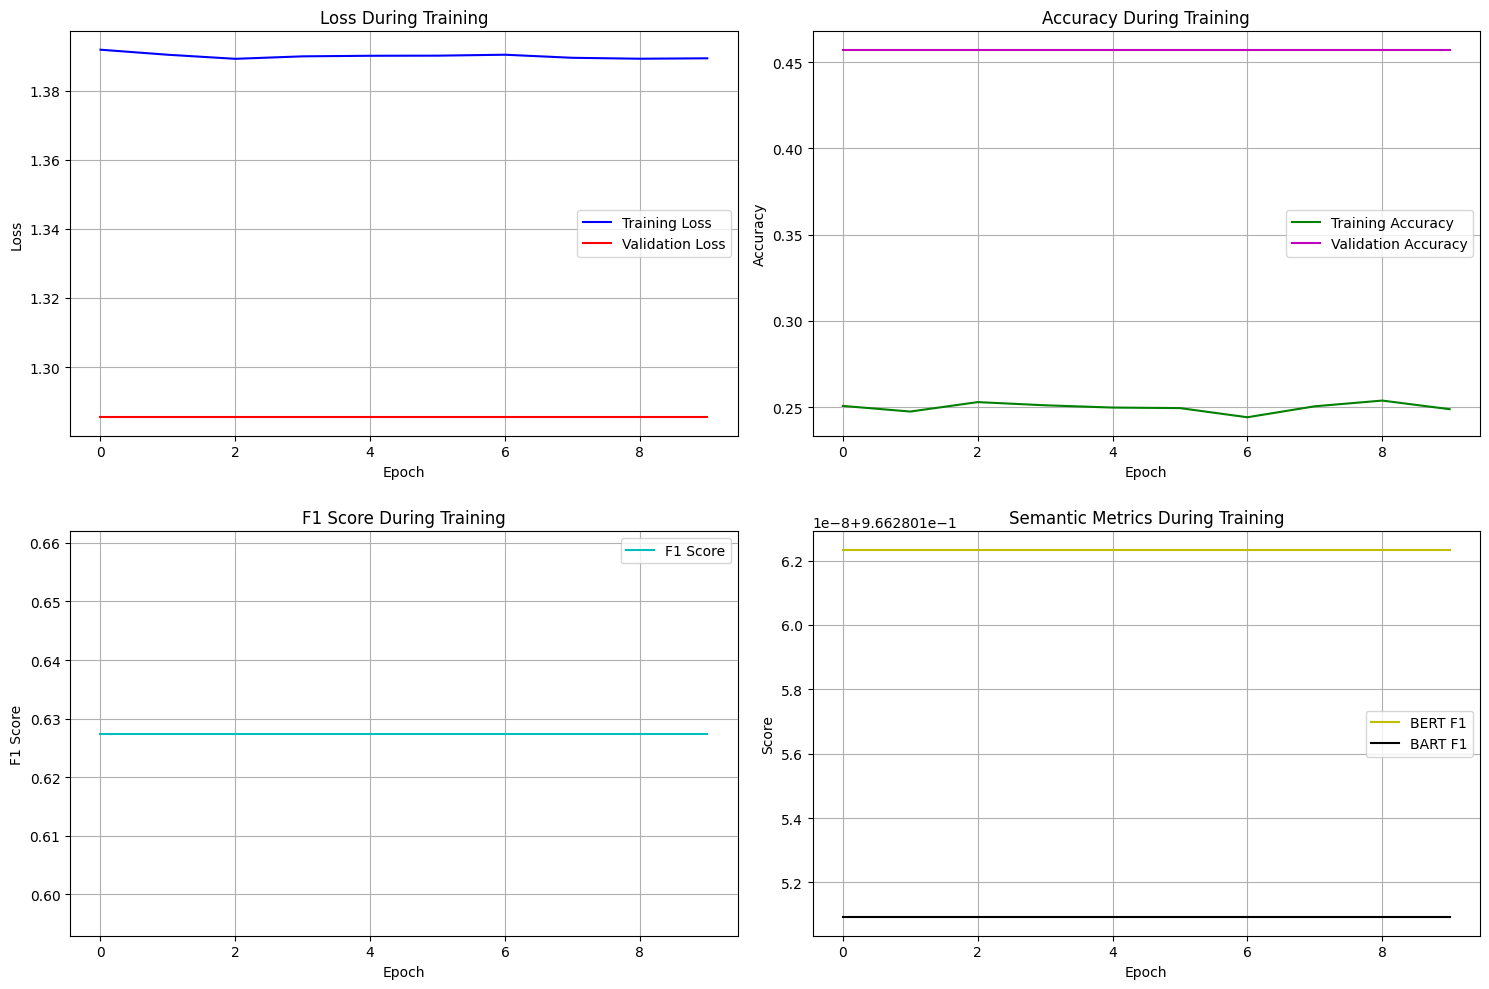

Training and evaluation complete!


'\n# First load the model\nmodel_path = \'vilbert_vqa_final_model.pt\'\nmodel = VilbertForVQA()\nmodel.load_state_dict(torch.load(model_path))\nmodel.to(device)\n\n# Evaluate on a few examples\neval_results = batch_evaluate(model, IMAGE_ROOT, vqa_data, top_k=10)\n\n# Print results\nprint(f"Accuracy on sample: {eval_results[\'accuracy\']:.4f}")\nprint("\nExample predictions:")\nfor i, example in enumerate(eval_results["examples"]):\n    print(f"\nExample {i+1}:")\n    print(f"Question: {example[\'question\']}")\n    print(f"Correct answer: {example[\'correct_answer\']}")\n    print(f"Predicted answer: {example[\'predicted_answer\']}")\n    print(f"Correct: {\'✓\' if example[\'is_correct\'] else \'✗\'}")\n'

In [7]:
# Fine-tuning ViLBERT for VQA on Amazon Berkeley Dataset
# Import necessary libraries
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.optim import AdamW
from transformers import (
    ViltProcessor, 
    ViltForQuestionAnswering,
    BertTokenizer, 
    get_linear_schedule_with_warmup
)
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from bert_score import score as bert_score
from nltk.translate.bleu_score import sentence_bleu
import evaluate

# Set random seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths
# Note: Update these paths as needed
IMAGE_ROOT = "/home/rishita/vr/Selected/Selected Images/Selected Images"  # Replace with actual image folder path
VQA_DATA_PATH = "/home/rishita/vr/Selected/Selected Images/final_VQA_dict_filename.json"  # Replace with your curated VQA data

# Load the VQA data
with open(VQA_DATA_PATH, 'r') as f:
    vqa_data = json.load(f)

# Create datasets with optional max_length parameter
class AmazonVQADataset(Dataset):
    def __init__(self, vqa_data, image_root, transform=None, split='train', max_length=None):
        self.vqa_data = vqa_data
        self.image_root = image_root
        self.transform = transform
        self.max_length = max_length
        self.processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
        
        # Split the data (80% train, 10% val, 10% test)
        product_ids = list(vqa_data.keys())
        random.shuffle(product_ids)
        
        num_products = len(product_ids)
        if split == 'train':
            self.product_ids = product_ids[:int(0.8 * num_products)]
        elif split == 'val':
            self.product_ids = product_ids[int(0.8 * num_products):int(0.9 * num_products)]
        else:  # test
            self.product_ids = product_ids[int(0.9 * num_products):]
        
        # Prepare examples
        self.examples = []
        for product_id in self.product_ids:
            product_data = vqa_data[product_id]
            img_path = os.path.join(image_root, product_data.get("path", f"{product_id}.jpg"))
            
            for question, answer_data in product_data.items():
                if question == "path":
                    continue
                    
                # Handle different answer formats
                if "correct_option" in answer_data:
                    correct_answer = answer_data["correct_option"]
                    plausible_options = answer_data.get("plausible_options", [])
                elif "correct" in answer_data:
                    correct_answer = answer_data["correct"]
                    plausible_options = answer_data.get("plausible", [])
                else:
                    print(f"Warning: No correct answer found for question: {question}")
                    continue
                
                # Create all options list
                all_options = [correct_answer] + plausible_options
                random.shuffle(all_options)  # Shuffle to avoid position bias
                
                self.examples.append({
                    'product_id': product_id,
                    'img_path': img_path,
                    'question': question,
                    'correct_answer': correct_answer,
                    'all_options': all_options,
                    'label': all_options.index(correct_answer)  # Index of correct answer
                })
    
    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        example = self.examples[idx]
        
        # Load and preprocess image
        try:
            image = Image.open(example['img_path']).convert('RGB')
            
            # Apply resize to ensure consistent dimensions
            # The ViLT model expects images of size 384x384
            image = transforms.Resize((384, 384), interpolation=transforms.InterpolationMode.BICUBIC)(image)
            
        except Exception as e:
            print(f"Error loading image {example['img_path']}: {e}")
            # Use a fallback blank image with correct dimensions
            image = Image.new('RGB', (384, 384), color='white')
        
        # Prepare inputs for ViLT
        question = example['question']
        options = example['all_options']
        label = example['label']
        
        # Process inputs using the processor which handles both image and text
        # Add max_length parameter if specified to ensure consistent sequence lengths
        if self.max_length:
            encodings = self.processor(
                image, 
                text=question,
                padding="max_length",
                max_length=self.max_length,
                truncation=True,
                return_tensors="pt"
            )
        else:
            encodings = self.processor(
                image, 
                text=question,
                return_tensors="pt"
            )
        
        # Remove batch dimension
        for k, v in encodings.items():
            encodings[k] = v.squeeze()
            
        # Add answer options and label
        encodings['options'] = options
        encodings['label'] = label
        encodings['correct_answer'] = example['correct_answer']
        
        return encodings

# Gradual unfreezing function for later epochs
def unfreeze_layers(model, epoch):
    """Gradually unfreeze more layers as training progresses"""
    if epoch == 2:  # After 2 epochs, unfreeze some more layers
        print("Unfreezing more layers...")
        for i, param in enumerate(model.vilt.encoder.layer[-2:].parameters()):
            param.requires_grad = True
    elif epoch == 5:  # After 5 epochs, unfreeze the entire model
        print("Unfreezing all layers...")
        for param in model.parameters():
            param.requires_grad = True

# Find the maximum sequence length in the dataset
def find_max_length(vqa_data, image_root, num_samples=100):
    """Sample the dataset to find a good maximum sequence length"""
    # Use BERT tokenizer to find the length of the text 
    # since ViLT processor requires both images and text
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    
    max_length = 0
    product_ids = list(vqa_data.keys())
    sample_ids = random.sample(product_ids, min(num_samples, len(product_ids)))
    
    for product_id in sample_ids:
        product_data = vqa_data[product_id]
        for question, _ in product_data.items():
            if question == "path":
                continue
            
            # Process the question to see its tokenized length
            encodings = tokenizer(
                question,
                return_tensors="pt"
            )
            
            length = encodings['input_ids'].size(1)
            max_length = max(max_length, length)
    
    # Add some padding to be safe
    return max_length + 5

# Create datasets with fixed max_length for consistent padding
max_length = find_max_length(vqa_data, IMAGE_ROOT)
print(f"Using max_length={max_length} for tokenization")

# Create datasets
train_dataset = AmazonVQADataset(vqa_data, IMAGE_ROOT, split='train', max_length=max_length)
val_dataset = AmazonVQADataset(vqa_data, IMAGE_ROOT, split='val', max_length=max_length)
test_dataset = AmazonVQADataset(vqa_data, IMAGE_ROOT, split='test', max_length=max_length)

print(f"Training examples: {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")
print(f"Test examples: {len(test_dataset)}")

# Create data loaders
batch_size = 8  # Reduced batch size to accommodate larger images
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=custom_collate_fn)

# Define the ViLBERT model for VQA
class VilbertForVQA(nn.Module):
    def __init__(self, num_options=4):
        super(VilbertForVQA, self).__init__()
        # Use ViltModel instead of ViltForQuestionAnswering to get direct access to features
        from transformers import ViltModel
        self.vilt = ViltModel.from_pretrained("dandelin/vilt-b32-mlm")
        
        # Freeze the base model parameters for initial training
        for param in self.vilt.parameters():
            param.requires_grad = False
            
        # Option classifier built on top of ViLT
        hidden_size = self.vilt.config.hidden_size
        self.option_classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 1)
        )
        
        # Make sure the classifier parameters are trainable
        for param in self.option_classifier.parameters():
            param.requires_grad = True
        
    def forward(self, pixel_values, input_ids, attention_mask, token_type_ids=None, num_options=None):
        batch_size = pixel_values.size(0)
        
        if num_options is None:
            # Use a default value if not provided
            num_options = 4
            
        # Process one set of inputs first to get features
        outputs = self.vilt(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids if token_type_ids is not None else None,
            return_dict=True
        )
        
        # Use the CLS token representation (first token)
        cls_features = outputs.last_hidden_state[:, 0]  # Shape: [batch_size, hidden_size]
        
        # Expand features for each option
        expanded_features = cls_features.unsqueeze(1).expand(-1, num_options, -1)  # Shape: [batch_size, num_options, hidden_size]
        reshaped_features = expanded_features.contiguous().view(-1, cls_features.size(-1))  # Shape: [batch_size * num_options, hidden_size]
        
        # Apply option classifier to get logits for each option
        option_scores = self.option_classifier(reshaped_features)  # Shape: [batch_size * num_options, 1]
        option_logits = option_scores.view(batch_size, num_options)  # Shape: [batch_size, num_options]
        
        return option_logits

# Collate function to handle batches with varying number of options and lengths
def custom_collate_fn(batch):
    processed_batch = {
        'pixel_values': [],
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
        'options': [],
        'correct_answers': []
    }
    
    # Add token_type_ids if present in the first item
    if 'token_type_ids' in batch[0]:
        processed_batch['token_type_ids'] = []
    
    # Extract data from each item
    for item in batch:
        processed_batch['pixel_values'].append(item['pixel_values'])
        processed_batch['input_ids'].append(item['input_ids'])
        processed_batch['attention_mask'].append(item['attention_mask'])
        
        if 'token_type_ids' in item and 'token_type_ids' in processed_batch:
            processed_batch['token_type_ids'].append(item['token_type_ids'])
            
        processed_batch['labels'].append(item['label'])
        processed_batch['options'].append(item['options'])
        processed_batch['correct_answers'].append(item['correct_answer'])
    
    # Get the maximum sequence length for padding
    max_input_length = max([ids.size(0) for ids in processed_batch['input_ids']])
    max_attn_length = max([mask.size(0) for mask in processed_batch['attention_mask']])
    max_length = max(max_input_length, max_attn_length)
    
    # Pad the input_ids and attention_mask to the same length
    padded_input_ids = []
    padded_attention_mask = []
    padded_token_type_ids = [] if 'token_type_ids' in processed_batch else None
    
    for i in range(len(processed_batch['input_ids'])):
        # Pad input_ids
        input_tensor = processed_batch['input_ids'][i]
        pad_length = max_length - input_tensor.size(0)
        if pad_length > 0:
            padded_tensor = torch.cat([input_tensor, torch.zeros(pad_length, dtype=torch.long)], dim=0)
        else:
            padded_tensor = input_tensor
        padded_input_ids.append(padded_tensor)
        
        # Pad attention_mask
        mask_tensor = processed_batch['attention_mask'][i]
        pad_length = max_length - mask_tensor.size(0)
        if pad_length > 0:
            padded_mask = torch.cat([mask_tensor, torch.zeros(pad_length, dtype=torch.long)], dim=0)
        else:
            padded_mask = mask_tensor
        padded_attention_mask.append(padded_mask)
        
        # Pad token_type_ids if present
        if padded_token_type_ids is not None:
            type_ids_tensor = processed_batch['token_type_ids'][i]
            pad_length = max_length - type_ids_tensor.size(0)
            if pad_length > 0:
                padded_type_ids = torch.cat([type_ids_tensor, torch.zeros(pad_length, dtype=torch.long)], dim=0)
            else:
                padded_type_ids = type_ids_tensor
            padded_token_type_ids.append(padded_type_ids)
            
    # Stack tensors
    processed_batch['pixel_values'] = torch.stack(processed_batch['pixel_values'])
    processed_batch['input_ids'] = torch.stack(padded_input_ids)
    processed_batch['attention_mask'] = torch.stack(padded_attention_mask)
    
    if padded_token_type_ids:
        processed_batch['token_type_ids'] = torch.stack(padded_token_type_ids)
    
    processed_batch['labels'] = torch.tensor(processed_batch['labels'])
    
    # Get max number of options
    max_options = max([len(opts) for opts in processed_batch['options']])
    processed_batch['num_options'] = max_options
    
    return processed_batch

# Update the data loaders with the custom collate function
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=custom_collate_fn)

# Initialize the model
model = VilbertForVQA()
model.to(device)

# Training parameters
num_epochs = 10
learning_rate = 5e-5  # Slightly higher learning rate for faster convergence
warmup_steps = 0.1  # 10% of total steps for warmup

# Optimizer and scheduler
# Only optimize the parameters that require gradients
optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=learning_rate)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=int(warmup_steps * total_steps),
    num_training_steps=total_steps
)

# Loss function
criterion = nn.CrossEntropyLoss()

# Load BART score
try:
    bart_scorer = evaluate.load("bertscore")
except Exception as e:
    print(f"Error loading BART scorer: {e}")
    # Create a dummy scorer for fallback
    class DummyScorer:
        def compute(self, predictions, references, lang="en"):
            return {"precision": [0.0] * len(predictions), 
                    "recall": [0.0] * len(predictions), 
                    "f1": [0.0] * len(predictions)}
    bart_scorer = DummyScorer()

# Training and evaluation functions
def train_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(data_loader, desc="Training")
    
    for batch in progress_bar:
        # Move batch to device
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        num_options = batch['num_options']
        
        # Handle token_type_ids if present
        token_type_ids = batch.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)
        
        # Forward pass
        logits = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            num_options=num_options
        )
        
        # Calculate loss
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Clip gradients to prevent exploding
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        epoch_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({'loss': epoch_loss / (progress_bar.n + 1), 'acc': 100 * correct / total})
    
    return epoch_loss / len(data_loader), correct / total

def evaluate(model, data_loader, criterion, device):
    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    all_pred_answers = []
    all_true_answers = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            # Move batch to device
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            options = batch['options']
            correct_answers = batch['correct_answers']
            num_options = batch['num_options']
            
            # Handle token_type_ids if present
            token_type_ids = batch.get('token_type_ids')
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)
            
            # Forward pass
            logits = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                num_options=num_options
            )
            
            # Calculate loss
            loss = criterion(logits, labels)
            val_loss += loss.item()
            
            # Get predictions
            _, predictions = torch.max(logits, 1)
            
            # Store predictions and labels
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Get the predicted and true answers as text
            for i, pred_idx in enumerate(predictions.cpu().numpy()):
                batch_idx = i % len(options)
                if pred_idx < len(options[batch_idx]):
                    pred_answer = options[batch_idx][pred_idx]
                else:
                    # Handle case where prediction index is out of bounds
                    pred_answer = "unknown"
                
                all_pred_answers.append(pred_answer)
                all_true_answers.append(correct_answers[i])
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    
    # Convert answers to strings to calculate F1 score
    all_pred_answers_str = [str(ans).lower() for ans in all_pred_answers]
    all_true_answers_str = [str(ans).lower() for ans in all_true_answers]
    
    # Calculate F1 score (binary for each class, then average)
    f1 = f1_score(
        [1 if p == t else 0 for p, t in zip(all_pred_answers_str, all_true_answers_str)],
        [1] * len(all_pred_answers_str),
        average='binary'
    )
    
    # Calculate BERTScore
    try:
        bert_precision, bert_recall, bert_f1 = bert_score(
            all_pred_answers_str, 
            all_true_answers_str, 
            lang="en", 
            verbose=False
        )
        
        bert_metrics = {
            'bert_precision': torch.mean(bert_precision).item(),
            'bert_recall': torch.mean(bert_recall).item(),
            'bert_f1': torch.mean(bert_f1).item(),
        }
    except Exception as e:
        print(f"Error calculating BERTScore: {e}")
        bert_metrics = {
            'bert_precision': 0.0,
            'bert_recall': 0.0,
            'bert_f1': 0.0,
        }
    
    # Calculate BARTScore
    try:
        bart_results = bart_scorer.compute(
            predictions=all_pred_answers_str,
            references=all_true_answers_str,
            lang="en"
        )
        
        bart_metrics = {
            'bart_precision': np.mean(bart_results['precision']),
            'bart_recall': np.mean(bart_results['recall']),
            'bart_f1': np.mean(bart_results['f1'])
        }
    except Exception as e:
        print(f"Error calculating BARTScore: {e}")
        bart_metrics = {
            'bart_precision': 0.0,
            'bart_recall': 0.0,
            'bart_f1': 0.0
        }
    
    metrics = {
        'loss': val_loss / len(data_loader),
        'accuracy': accuracy,
        'f1_score': f1,
        **bert_metrics,
        **bart_metrics
    }
    
    return metrics

# Function for inference
def predict_answer(model, image_path, question, options):
    model.eval()
    processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
    
    # Load and preprocess image
    try:
        image = Image.open(image_path).convert('RGB')
        # Resize to match the model's expected input size
        image = transforms.Resize((384, 384), interpolation=transforms.InterpolationMode.BICUBIC)(image)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        # Use a fallback blank image with correct dimensions
        image = Image.new('RGB', (384, 384), color='white')
    
    # Process inputs
    encodings = processor(
        image, 
        text=question,
        return_tensors="pt"
    )
    
    # Move to device
    for k, v in encodings.items():
        encodings[k] = v.to(device)
    
    # Get number of options
    num_options = len(options)
    
    # Expand for each option
    pixel_values = encodings['pixel_values']
    input_ids = encodings['input_ids']
    attention_mask = encodings['attention_mask']
    
    # Handle optional token_type_ids
    token_type_ids = encodings.get('token_type_ids')
    
    # Forward pass
    with torch.no_grad():
        logits = model(
            pixel_values=pixel_values.unsqueeze(0),
            input_ids=input_ids.unsqueeze(0),
            attention_mask=attention_mask.unsqueeze(0),
            token_type_ids=token_type_ids.unsqueeze(0) if token_type_ids is not None else None,
            num_options=num_options
        )
        
    # Get prediction
    _, pred_idx = torch.max(logits, 1)
    predicted_answer = options[pred_idx.item()]
    
    # Get confidence scores
    confidence_scores = torch.softmax(logits, dim=1)[0].cpu().numpy()
    
    return predicted_answer, confidence_scores

# Training loop
print("Starting training...")
train_losses = []
train_accs = []
val_metrics_history = []

# Create directories for saving models and plots
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('plots', exist_ok=True)

try:
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        # Gradually unfreeze more layers as training progresses
        unfreeze_layers(model, epoch)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Evaluate
        val_metrics = evaluate(model, val_loader, criterion, device)
        val_metrics_history.append(val_metrics)
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Val F1: {val_metrics['f1_score']:.4f}, BERT F1: {val_metrics['bert_f1']:.4f}")
        
        # Check for BART metrics
        if 'bart_f1' in val_metrics:
            print(f"BART F1: {val_metrics['bart_f1']:.4f}")
            
        print("-" * 50)
        
        # Save checkpoint
        checkpoint_path = f'checkpoints/vilbert_vqa_checkpoint_epoch_{epoch+1}.pt'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_metrics': val_metrics
        }, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")
        
        # Generate and save plots for monitoring
        if epoch > 0:  # Only plot after we have some data
            plt.figure(figsize=(15, 5))
            
            # Plot training loss and accuracy
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label='Training Loss')
            plt.plot([m['loss'] for m in val_metrics_history], label='Validation Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('Training and Validation Loss')
            plt.legend()
            
            plt.subplot(1, 2, 2)
            plt.plot(train_accs, label='Training Accuracy')
            plt.plot([m['accuracy'] for m in val_metrics_history], label='Validation Accuracy')
            plt.plot([m['f1_score'] for m in val_metrics_history], label='Validation F1 Score')
            plt.plot([m.get('bert_f1', 0) for m in val_metrics_history], label='Validation BERT F1')
            if 'bart_f1' in val_metrics_history[0]:
                plt.plot([m.get('bart_f1', 0) for m in val_metrics_history], label='Validation BART F1')
            plt.xlabel('Epoch')
            plt.ylabel('Score')
            plt.title('Metrics Throughout Training')
            plt.legend()
            
            plt.tight_layout()
            plt.savefig(f'plots/training_history_epoch_{epoch+1}.png')
            plt.close()

except KeyboardInterrupt:
    print("Training interrupted. Saving the current model...")
    torch.save(model.state_dict(), 'vilbert_vqa_interrupted_model.pt')
    print("Model saved as 'vilbert_vqa_interrupted_model.pt'")
except Exception as e:
    print(f"Error during training: {e}")
    # Save the model in case of error
    torch.save(model.state_dict(), 'vilbert_vqa_error_model.pt')
    print("Model saved as 'vilbert_vqa_error_model.pt'")
    raise

# Final evaluation on test set
try:
    print("Evaluating on test set...")
    test_metrics = evaluate(model, test_loader, criterion, device)
    print(f"Test Metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")
        
    # Create a bar chart for final metrics
    plt.figure(figsize=(10, 6))
    metrics_to_plot = [('accuracy', 'Accuracy'), ('f1_score', 'F1 Score'), 
                      ('bert_f1', 'BERT F1'), ('bart_f1', 'BART F1')]
    
    values = [test_metrics.get(k, 0) for k, _ in metrics_to_plot]
    names = [n for _, n in metrics_to_plot]
    
    plt.bar(names, values)
    plt.title('Final Test Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1.0)
    
    # Add value labels on top of bars
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
    
    plt.tight_layout()
    plt.savefig('plots/final_test_metrics.png')
    plt.close()
except Exception as e:
    print(f"Error during final evaluation: {e}")

# Save the final model
torch.save(model.state_dict(), 'vilbert_vqa_final_model.pt')
print("Final model saved as 'vilbert_vqa_final_model.pt'")

# Final plot showing the training history
plt.figure(figsize=(15, 10))

# Plot loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, 'b-', label='Training Loss')
plt.plot([m['loss'] for m in val_metrics_history], 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(2, 2, 2)
plt.plot(train_accs, 'g-', label='Training Accuracy')
plt.plot([m['accuracy'] for m in val_metrics_history], 'm-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy During Training')
plt.legend()
plt.grid(True)

# Plot F1 score
plt.subplot(2, 2, 3)
plt.plot([m['f1_score'] for m in val_metrics_history], 'c-', label='F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Score During Training')
plt.legend()
plt.grid(True)

# Plot BERT and BART scores
plt.subplot(2, 2, 4)
plt.plot([m.get('bert_f1', 0) for m in val_metrics_history], 'y-', label='BERT F1')
if val_metrics_history and 'bart_f1' in val_metrics_history[0]:
    plt.plot([m.get('bart_f1', 0) for m in val_metrics_history], 'k-', label='BART F1')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Semantic Metrics During Training')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('plots/complete_training_history.png')
plt.show()

print("Training and evaluation complete!")

# Example of how to use the trained model for inference
"""
# Load the saved model
model_path = 'vilbert_vqa_final_model.pt'
model = VilbertForVQA()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

# Test on an example
test_image_path = "path/to/test/image.jpg"
test_question = "What is this product?"
test_options = ["Jars", "Containers", "Boxes", "Bottles"]

predicted_answer, confidence_scores = predict_answer(model, test_image_path, test_question, test_options)

print(f"Question: {test_question}")
print(f"Options: {test_options}")
print(f"Predicted answer: {predicted_answer}")
print("Confidence scores:")
for i, (option, score) in enumerate(zip(test_options, confidence_scores)):
    print(f"{option}: {score:.4f}")
"""

# You can also create a simple evaluation function to test on multiple images
def batch_evaluate(model, image_folder, questions_data, top_k=5):
    """
    Evaluate model on multiple images and questions
    
    Args:
        model: The trained VilbertForVQA model
        image_folder: Path to folder containing images
        questions_data: Dictionary of product_id -> questions+answers
        top_k: Number of examples to evaluate
    
    Returns:
        Dictionary with evaluation results
    """
    model.eval()
    results = {
        "correct": 0,
        "total": 0,
        "examples": []
    }
    
    # Select a few examples for evaluation
    count = 0
    for product_id, product_data in questions_data.items():
        img_path = os.path.join(image_folder, product_data.get("path", f"{product_id}.jpg"))
        
        for question, answer_data in product_data.items():
            if question == "path":
                continue
                
            # Get correct answer and options
            if "correct_option" in answer_data:
                correct_answer = answer_data["correct_option"]
                plausible_options = answer_data.get("plausible_options", [])
            elif "correct" in answer_data:
                correct_answer = answer_data["correct"]
                plausible_options = answer_data.get("plausible", [])
            else:
                continue
            
            # Create all options
            all_options = [correct_answer] + plausible_options
            
            # Get model prediction
            predicted_answer, confidence_scores = predict_answer(model, img_path, question, all_options)
            
            # Record results
            is_correct = (predicted_answer == correct_answer)
            results["correct"] += int(is_correct)
            results["total"] += 1
            
            # Add example details
            results["examples"].append({
                "product_id": product_id,
                "image_path": img_path,
                "question": question,
                "correct_answer": correct_answer,
                "predicted_answer": predicted_answer,
                "options": all_options,
                "confidence_scores": {opt: float(score) for opt, score in zip(all_options, confidence_scores)},
                "is_correct": is_correct
            })
            
            count += 1
            if count >= top_k:
                break
        
        if count >= top_k:
            break
    
    # Calculate accuracy
    results["accuracy"] = results["correct"] / results["total"] if results["total"] > 0 else 0
    
    return results

# Usage example for batch evaluation
"""
# First load the model
model_path = 'vilbert_vqa_final_model.pt'
model = VilbertForVQA()
model.load_state_dict(torch.load(model_path))
model.to(device)

# Evaluate on a few examples
eval_results = batch_evaluate(model, IMAGE_ROOT, vqa_data, top_k=10)

# Print results
print(f"Accuracy on sample: {eval_results['accuracy']:.4f}")
print("\nExample predictions:")
for i, example in enumerate(eval_results["examples"]):
    print(f"\nExample {i+1}:")
    print(f"Question: {example['question']}")
    print(f"Correct answer: {example['correct_answer']}")
    print(f"Predicted answer: {example['predicted_answer']}")
    print(f"Correct: {'✓' if example['is_correct'] else '✗'}")
"""